# Section 2.3 Combined Random Forest Models

In [1]:
# Python version check
import sys
assert sys.version_info >= (3, 5), "Python 3.5 or later is required."

# Scikit-Learn version check
import sklearn
assert sklearn.__version__ >= "0.20", "Scikit-Learn 0.20 or later is required."

# Common imports
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib and Seaborn
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
sns.set()

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate

# Utility libraries
import shutil
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Custom utility imports
from rf_utils import (
    feature_selection,
    plot_feature_selection_base,
    plot_feature_rank,
    plot_green_line,
    save_important_features,
    tune_random_forest
)

## Section 3.1 Method 1 - Single Model

In [2]:
# === CONFIGURATION ===
# Set model paths
fso_model_path = "saved_models/method1/generic_fso_best_model.pkl"
rf_model_path = "saved_models/method1/generic_rf_best_model.pkl"

# Set dataset paths
x_train_path = "Data/Splitting/Train/Generic/X/X_train.csv"
x_val_path = "Data/Splitting/Validation/Generic/X/X_val.csv"

y_train_fso_path = "Data/Splitting/Train/Generic/Y/y_train_FSO.csv"
y_val_fso_path = "Data/Splitting/Validation/Generic/Y/y_val_FSO.csv"
y_train_rf_path = "Data/Splitting/Train/Generic/Y/y_train_RF.csv"
y_val_rf_path = "Data/Splitting/Validation/Generic/Y/y_val_RF.csv"

# Set updated X input features (after feature selection)
updated_x_train_fso_path = "Data/Splitting/Train/Generic/X/updated_Generic_FSO.csv"
updated_x_val_fso_path = "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Generic.csv"

updated_x_train_rf_path = "Data/Splitting/Train/Generic/X/updated_Generic_RF.csv"
updated_x_val_rf_path = "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Generic.csv"

# Set output paths
output_train_fso_path = "Data/Predicted/Train/train_with_predicted_FSO.csv"
output_val_fso_path = "Data/Predicted/Validation/val_with_predicted_FSO.csv"
output_val_m2_path = "Data/Predicted/Validation/val_with_predicted_m2.csv"

output_train_rf_path = "Data/Predicted/Train/train_with_predicted_RF.csv"
output_val_rf_path = "Data/Predicted/Validation/val_with_predicted_RF.csv"
output_val_m3_path = "Data/Predicted/Validation/val_with_predicted_m3.csv"

os.makedirs("Data/Predicted/Train", exist_ok=True)
os.makedirs("Data/Predicted/Validation", exist_ok=True)

**(1) Single Model - FSO**

In [3]:
def predict_and_save(model_path, x_path, original_x_path, y_path, output_path, label):
    """
    Predict and save results using a saved Random Forest model.

    Parameters:
    - model_path (str): Path to the saved model file.
    - x_path (str): Path to the processed feature dataset (X).
    - original_x_path (str): Path to the original feature dataset (X_original).
    - y_path (str): Path to the target dataset (y).
    - output_path (str): Path to save the dataset with predictions.
    - label (str): Label for the predictions (e.g., "FSO", "RF").
    - results_path (str, optional): Path to save the RMSE and R² results as a CSV file.

    Returns:
    - results (list): List of dictionaries containing RMSE and R² for overall and per-SC metrics.
    """
    
    # Load saved model and extract best params
    saved_model = joblib.load(model_path)
    best_params = saved_model['Best Params']

    # Reconstruct model
    model = RandomForestRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        random_state=42
    )

    # Load data
    X = pd.read_csv(x_path)
    X_original = pd.read_csv(original_x_path)
    y = pd.read_csv(y_path).squeeze()

    # Fit and predict
    model.fit(X, y)
    y_pred = model.predict(X)

    # Append predictions to original data and save
    X_original[f"Predicted_{label}"] = y_pred
    X_original.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

    # === Overall metrics ===
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    print(f"[{label}] Overall - RMSE: {rmse:.4f}, R²: {r2:.4f}")

    results = [{'Model': 'Generic', 'SC': 'All', 'RMSE': rmse, 'R2': r2}]

    # === Per-SC metrics ===
    if 'SC' in X_original.columns:
        print(f"\n[{label}] Metrics by SYNOP Code:")
        for sc in sorted(X_original['SC'].unique()):
            mask = X_original['SC'] == sc
            sc_rmse = np.sqrt(mean_squared_error(y[mask], y_pred[mask]))
            sc_r2 = r2_score(y[mask], y_pred[mask])
            print(f"  SC {sc} - RMSE: {sc_rmse:.4f}, R²: {sc_r2:.4f}")
            results.append({'Model': 'Generic', 'SC': sc, 'RMSE': sc_rmse, 'R2': sc_r2})
    print()
    return results


In [4]:
# RUN FSO Predictions
m1_fso_train_results = predict_and_save(
    model_path=fso_model_path,
    x_path=updated_x_train_fso_path,
    original_x_path=x_train_path,
    y_path=y_train_fso_path,
    output_path=output_train_fso_path,
    label="FSO"
)

m1_fso_val_results = predict_and_save(
    model_path=fso_model_path,
    x_path=updated_x_val_fso_path,
    original_x_path=x_val_path,
    y_path=y_val_fso_path,
    output_path=output_val_fso_path,
    label="FSO"
)

Saved: Data/Predicted/Train/train_with_predicted_FSO.csv
[FSO] Overall - RMSE: 0.4157, R²: 0.9887

[FSO] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.4122, R²: 0.9864
  SC 3 - RMSE: 0.6166, R²: 0.9946
  SC 4 - RMSE: 0.3425, R²: 0.9922
  SC 5 - RMSE: 0.3750, R²: 0.9890
  SC 6 - RMSE: 0.4260, R²: 0.9903
  SC 7 - RMSE: 0.6297, R²: 0.9866
  SC 8 - RMSE: 0.4510, R²: 0.9867

Saved: Data/Predicted/Validation/val_with_predicted_FSO.csv
[FSO] Overall - RMSE: 0.4677, R²: 0.9852

[FSO] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.4399, R²: 0.9841
  SC 3 - RMSE: 1.1285, R²: 0.9768
  SC 4 - RMSE: 0.4689, R²: 0.9884
  SC 5 - RMSE: 0.4331, R²: 0.9847
  SC 6 - RMSE: 0.5078, R²: 0.9853
  SC 7 - RMSE: 0.9854, R²: 0.9598
  SC 8 - RMSE: 0.5545, R²: 0.9828



**(2) Single Model - RF**

In [5]:
# RUN RF Predictions
m1_rf_train_results = predict_and_save(
    model_path=rf_model_path,
    x_path=updated_x_train_rf_path,
    original_x_path=x_train_path,
    y_path=y_train_rf_path,
    output_path=output_train_rf_path,
    label="RF"
)

m1_rf_val_results = predict_and_save(
    model_path=rf_model_path,
    x_path=updated_x_val_rf_path,
    original_x_path=x_val_path,
    y_path=y_val_rf_path,
    output_path=output_val_rf_path,
    label="RF"
)


Saved: Data/Predicted/Train/train_with_predicted_RF.csv
[RF] Overall - RMSE: 0.3329, R²: 0.9905

[RF] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.3093, R²: 0.9852
  SC 3 - RMSE: 0.1997, R²: 0.9956
  SC 4 - RMSE: 0.1652, R²: 0.9897
  SC 5 - RMSE: 0.3031, R²: 0.9890
  SC 6 - RMSE: 0.3809, R²: 0.9910
  SC 7 - RMSE: 0.1880, R²: 0.9861
  SC 8 - RMSE: 0.4847, R²: 0.9747

Saved: Data/Predicted/Validation/val_with_predicted_RF.csv
[RF] Overall - RMSE: 0.3369, R²: 0.9906

[RF] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.2800, R²: 0.9882
  SC 3 - RMSE: 0.2546, R²: 0.9937
  SC 4 - RMSE: 0.2459, R²: 0.9861
  SC 5 - RMSE: 0.3024, R²: 0.9894
  SC 6 - RMSE: 0.4362, R²: 0.9885
  SC 7 - RMSE: 0.2527, R²: 0.9686
  SC 8 - RMSE: 0.5261, R²: 0.9744



# Section 3.2 Method 2 - FSO-RF

**(1) Feature Selection**

In [6]:
# Load features (with predicted FSO already added)
X_method2 = pd.read_csv("Data/Predicted/Train/train_with_predicted_FSO.csv")
# Load the target: real RF attenuation
y_method2 = pd.read_csv("Data/Splitting/Train/Generic/Y/y_train_RF.csv").squeeze()

# Run feature selection
method2_results = feature_selection(X_method2, y_method2)

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


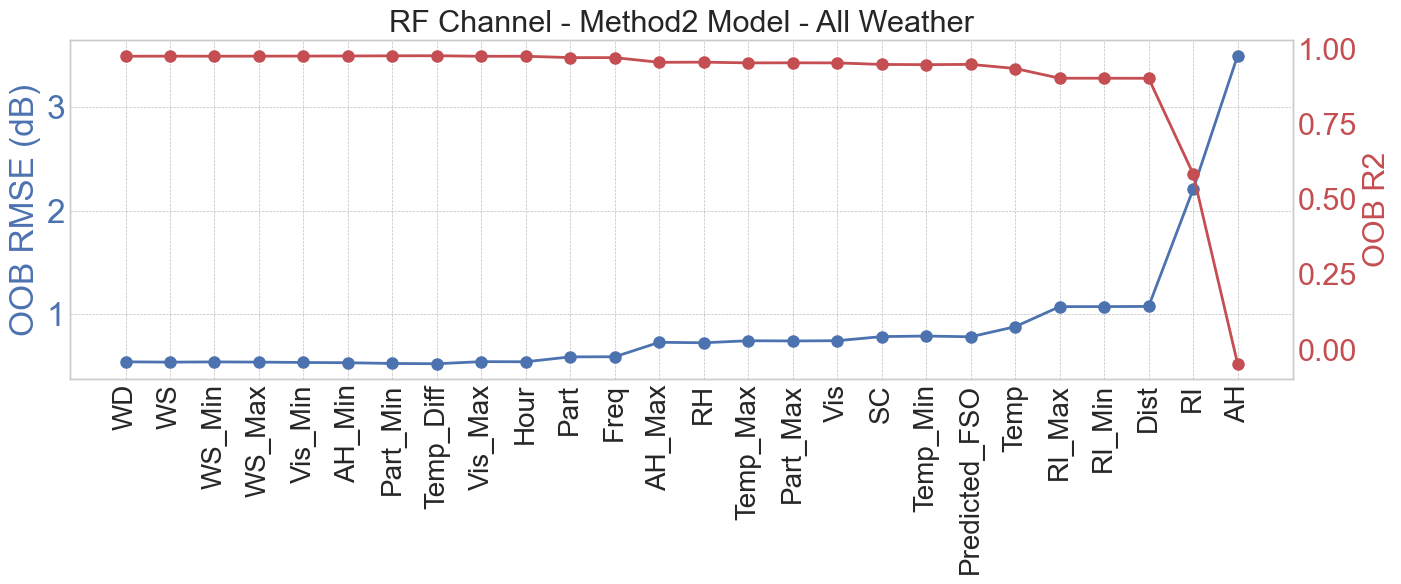

In [7]:
plot_feature_rank(
    important_features=method2_results['important_features'],
    rmse_list=method2_results['rmse_list'],
    r2_list=method2_results['r2_list'],
    file_prefix="RF_Method2"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


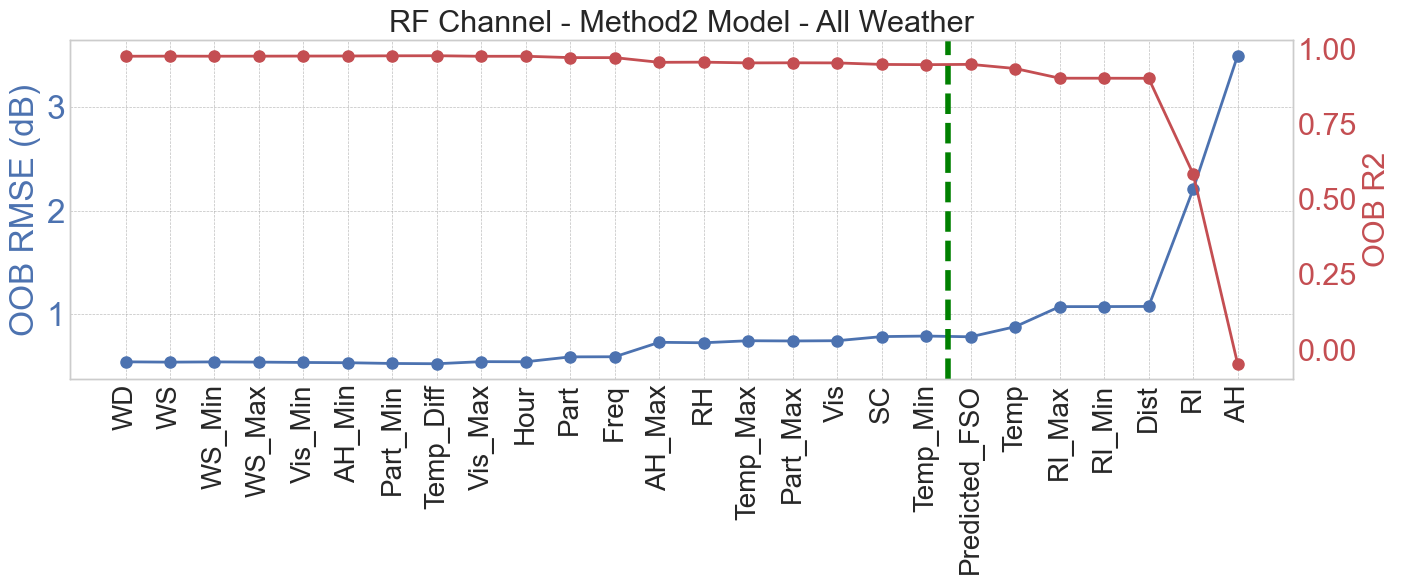

In [8]:
plot_green_line(    
    important_features=method2_results['important_features'],
    rmse_list=method2_results['rmse_list'],
    r2_list=method2_results['r2_list'],
    file_prefix="RF_Method2",
    point="Temp_Min"
)

In [9]:
# Define the important features for Method 2 (RF)
m2_important_features_rf = [
    'Predicted_FSO', 'Temp', 'RI_Max', 'Temp_Min', 
    'RI_Min', 'Dist', 'RI', 'AH'
]

# Select the important features from the dataset
X_method2_updated = X_method2[m2_important_features_rf]

**(2) Tuning Hyperparameters and Saving the Best Random Forest Model for RF (Method 2)**

In [10]:
# Define a function to tune, save, and log the model
def tune_and_save_model(X, y, method_name, model_name, save_path):
    """
    Tune a Random Forest model, save the best model, and log the results.

    Parameters:
    - X (DataFrame): Feature dataset.
    - y (Series): Target variable.
    - method_name (str): Name of the method (e.g., "Method 2").
    - model_name (str): Name of the model (e.g., "Generic_RF").
    - save_path (str): Path to save the tuned model.

    Returns:
    - model_info (dict): Dictionary containing the tuned model's details.
    """
    # Call the tuning function
    best_params, mean_rmse, std_rmse = tune_random_forest(X, y)

    # Print results for the current model
    print(f"Results for {method_name}-{model_name} :")
    print(f"  Best Params: {best_params}")
    print(f"  Mean RMSE: {mean_rmse:.4f}")
    print(f"  Std RMSE: {std_rmse:.4f}")
    print('')

    # Create a dictionary to store model details
    model_info = {
        'Model': model_name,
        'Best Params': best_params,
        'Mean RMSE': mean_rmse,
        'Std RMSE': std_rmse
    }

    # Ensure the save directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save the model
    joblib.dump(model_info, save_path)
    print(f"{model_name} saved to {save_path}")

    return model_info

In [11]:
# Call the function for Method 2
m2_rf2_model = tune_and_save_model(
    X=X_method2_updated,
    y=y_method2,
    method_name="Method 2",
    model_name="Generic_RF",
    save_path="saved_models/method2/best_model2_rfprediction.pkl"
)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 0.7923
Standard Deviation of RMSE: 0.0239
Results for Method 2-Generic_RF :
  Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 0.7923
  Std RMSE: 0.0239

Generic_RF saved to saved_models/method2/best_model2_rfprediction.pkl


In [12]:
m2_rf_model_path = "saved_models/method2/best_model2_rfprediction.pkl"

# RUN METHOD 2 RF Predictions
m2_val_results = predict_and_save(
    model_path=m2_rf_model_path,
    x_path=output_val_fso_path,         # This contains Predicted_FSO as a feature
    original_x_path=output_val_fso_path,  # Same file to add Predicted_RF
    y_path=y_val_rf_path,
    output_path=output_val_m2_path,
    label="RF"
)

Saved: Data/Predicted/Validation/val_with_predicted_m2.csv
[RF] Overall - RMSE: 0.2803, R²: 0.9935

[RF] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.2147, R²: 0.9931
  SC 3 - RMSE: 0.2859, R²: 0.9920
  SC 4 - RMSE: 0.2850, R²: 0.9813
  SC 5 - RMSE: 0.2541, R²: 0.9925
  SC 6 - RMSE: 0.3858, R²: 0.9910
  SC 7 - RMSE: 0.2380, R²: 0.9721
  SC 8 - RMSE: 0.4344, R²: 0.9825



# Section 3.3 Method 3 - RF-FSO

In [13]:
# Load features (with predicted RF already added)
X_method3 = pd.read_csv("Data/Predicted/Train/train_with_predicted_RF.csv")
# Load the target: real FSO attenuation
y_method3 = pd.read_csv("Data/Splitting/Train/Generic/Y/y_train_FSO.csv").squeeze()

**(1) Feature Selection**

In [14]:
# Run feature selection
method3_results = feature_selection(X_method3.drop(columns=["Freq"]), y_method3)

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


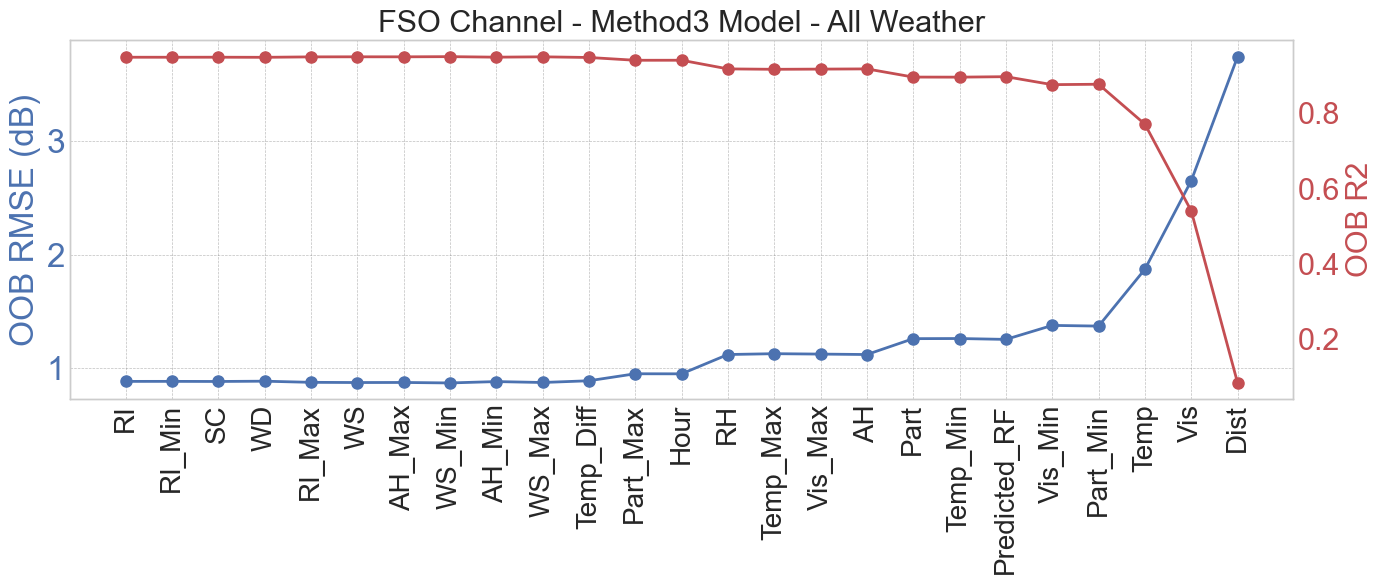

In [15]:
plot_feature_rank(
    important_features=method3_results['important_features'],
    rmse_list=method3_results['rmse_list'],
    r2_list=method3_results['r2_list'],
    file_prefix="FSO_Method3"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


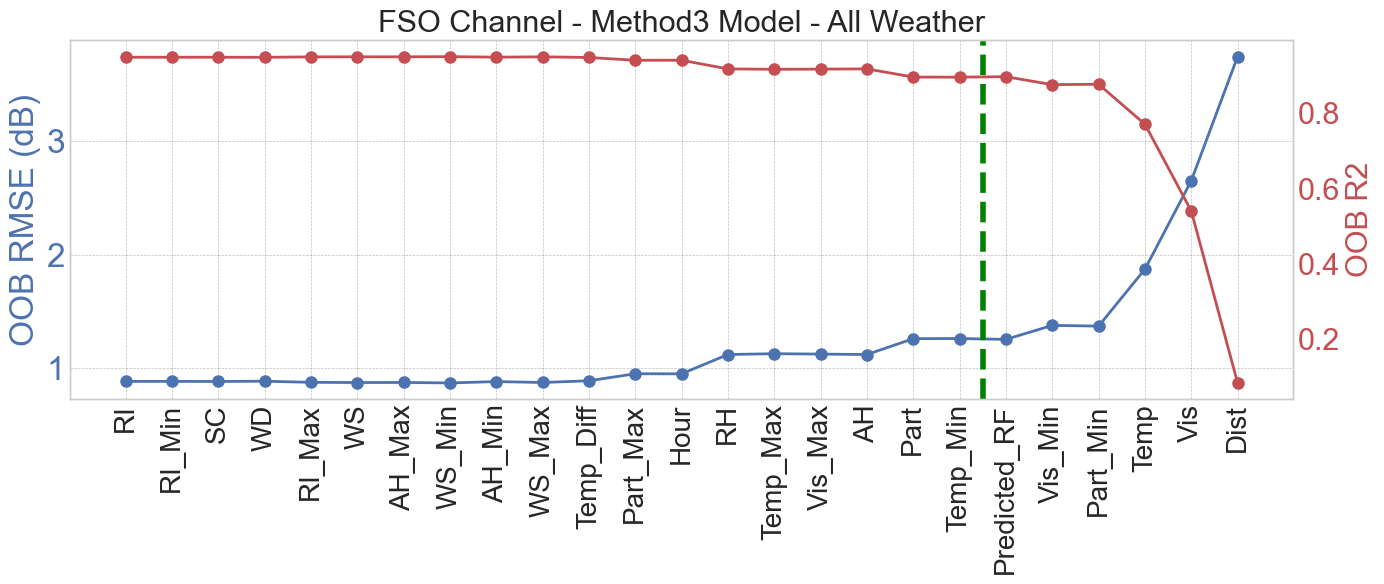

In [16]:
plot_green_line(
    important_features=method3_results['important_features'],
    rmse_list=method3_results['rmse_list'],
    r2_list=method3_results['r2_list'],
    file_prefix="FSO_Method3",
    point="Temp_Min"
)

In [17]:
# Define the important features for Method 3 (FSO)
m3_important_feature_FSO = [
    'Predicted_RF','Vis_Min', 'Part_Min', 
    'Temp', 'Vis', 'Dist'
]

# Select the important features from the dataset
X_method3_updated = X_method3[m3_important_feature_FSO]

**(2) Tuning Hyperparameters and Saving the Best Random Forest Model for FSO (Method 3)**

In [18]:
# Call the function for Method 3
m3_rf2_model = tune_and_save_model(
    X=X_method3_updated,
    y=y_method3,
    method_name="Method 3",
    model_name="Generic_FSO",
    save_path="saved_models/method3/best_model2_fsoprediction.pkl"
)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 1.2658
Standard Deviation of RMSE: 0.0260
Results for Method 3-Generic_FSO :
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 1.2658
  Std RMSE: 0.0260

Generic_FSO saved to saved_models/method3/best_model2_fsoprediction.pkl


In [19]:
m3_rf_model_path = "saved_models/method3/best_model2_fsoprediction.pkl"

# RUN METHOD 3 FSO Predictions
m3_val_results = predict_and_save(
    model_path=m3_rf_model_path,
    x_path=output_val_rf_path,           # This contains Predicted_FSO as a feature
    original_x_path=output_val_rf_path,  # Add Predicted_FSO to same file
    y_path=y_val_fso_path,
    output_path=output_val_m3_path,
    label="FSO"
)


Saved: Data/Predicted/Validation/val_with_predicted_m3.csv
[FSO] Overall - RMSE: 0.4233, R²: 0.9878

[FSO] Metrics by SYNOP Code:
  SC 0 - RMSE: 0.3986, R²: 0.9869
  SC 3 - RMSE: 1.1582, R²: 0.9755
  SC 4 - RMSE: 0.3480, R²: 0.9936
  SC 5 - RMSE: 0.3950, R²: 0.9873
  SC 6 - RMSE: 0.4582, R²: 0.9880
  SC 7 - RMSE: 0.8773, R²: 0.9681
  SC 8 - RMSE: 0.4852, R²: 0.9868

